# Notebook 02 — Preparación de los Datos (CRISP-DM Fase 3)

**Proyecto:** Clasificación universal de calidad de frutas
**Curso:** Algoritmos y Programación III — ICESI 2026-1
**Fase CRISP-DM:** 3. Preparación de los datos

## Objetivos

1. Aplicar el pipeline de `src/data/preprocess.py`: filtrado, split estratificado 70/15/15, persistencia en `data/processed/`.
2. **Verificar** que los splits preservan la distribución global de las 3 clases (`quality`) y de las 6 frutas.
3. Mostrar el efecto del **filtrado** (qué imágenes se descartan).
4. Demostrar el pipeline de **data augmentation** sobre una imagen ejemplo.
5. Probar la **extracción de features** (`src/utils/features.py`, vector 141-D) sobre una muestra.
6. Visualizar las features en un espacio 2D (PCA) para ver separabilidad preliminar entre clases.

## Salidas

- `data/processed/{train,val,test}_manifest.csv` (no se versionan; se regeneran con `python src/data/preprocess.py`).
- Figuras vectoriales en `outputs/figures/prep/`.


In [2]:
# Setup
from __future__ import annotations
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from src.data.preprocess import (
    load_manifest, filter_small_images, stratified_split, save_splits,
    load_and_preprocess_image, get_train_augmentation, get_val_augmentation,
    CLASS_NAMES, MIN_SIDE, IMG_SIZE, SPLIT_SIZES, RANDOM_STATE,
)
from src.utils.features import extract_features, feature_names, FEATURE_DIM

FIG_DIR = REPO_ROOT / "outputs" / "figures" / "prep"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 100, "savefig.format": "svg", "savefig.bbox": "tight",
                     "font.size": 10, "axes.titlesize": 11})
sns.set_style("whitegrid")

QUALITY_COLORS = {"Good": "#2ca02c", "Regular": "#ff7f0e", "Bad": "#d62728"}
print(f"Repo: {REPO_ROOT}")
print(f"FEATURE_DIM = {FEATURE_DIM}, IMG_SIZE = {IMG_SIZE}, SPLIT_SIZES = {SPLIT_SIZES}")


Repo: C:\Users\Kevin Cifuentes\Desktop\Estudios\APO3\Proyecto\APO3_TrabajoFinal\APO3_TrabajoFinal\Apo3_ProyectoFinal
FEATURE_DIM = 141, IMG_SIZE = (224, 224), SPLIT_SIZES = (0.7, 0.15, 0.15)


## 1. Cargar manifest y aplicar el pipeline

Reproducimos en el notebook lo que hace `src/data/preprocess.py` (`main`) para ver paso a paso qué pasa.


In [3]:
df = load_manifest()
print(f"Manifest original: {len(df):,} filas")

df_clean = filter_small_images(df, min_side=MIN_SIDE)
print(f"Despues del filtro (< {MIN_SIDE} px): {len(df_clean):,} ({100*len(df_clean)/len(df):.2f}%)")

Manifest original: 9,515 filas
[preprocess] Filtrado: descartadas 1712 imagenes con lado < 64 px (17.99% del total). Quedan 7803.
Despues del filtro (< 64 px): 7,803 (82.01%)


### 1.1 ¿Qué se descarta?

Las imágenes con cualquier lado < 64 px son patches/thumbnails que otros grupos del curso subieron cortadas. No son fotos reales utilizables para CNN a 224×224.


In [4]:
dropped = df[(df["width"] < MIN_SIDE) | (df["height"] < MIN_SIDE)]
print(f"Descartadas: {len(dropped):,}\n")
print("Top clases mas afectadas:")
print(dropped["class"].value_counts().head(8).to_string())
print(f"\nTamano mediano de las descartadas: {dropped['width'].median():.0f} x {dropped['height'].median():.0f}")

Descartadas: 1,712

Top clases mas afectadas:
class
Banana_Bad        470
Apple_Regular     454
Banana_Regular    400
Guava_Regular     356
Lime_Regular       32

Tamano mediano de las descartadas: 51 x 51


## 2. Split estratificado 70/15/15

Estratificamos por la columna `class` (las 18 combinaciones Fruit_Quality) para que train/val/test conserven proporciones equilibradas tanto por calidad como por fruta.


In [5]:
df_train, df_val, df_test = stratified_split(df_clean)
print(f"train: {len(df_train):,}  |  val: {len(df_val):,}  |  test: {len(df_test):,}")
print(f"Suma: {len(df_train)+len(df_val)+len(df_test):,}  ==  clean: {len(df_clean):,}")
assert len(df_train)+len(df_val)+len(df_test) == len(df_clean), "split no cuadra"
# No overlap
ov_tv = set(df_train["path"]) & set(df_val["path"])
ov_tt = set(df_train["path"]) & set(df_test["path"])
ov_vt = set(df_val["path"]) & set(df_test["path"])
print(f"Overlap train/val: {len(ov_tv)} | train/test: {len(ov_tt)} | val/test: {len(ov_vt)}  (debe ser 0)")

train: 5,461  |  val: 1,171  |  test: 1,171
Suma: 7,803  ==  clean: 7,803
Overlap train/val: 0 | train/test: 0 | val/test: 0  (debe ser 0)


### 2.1 Verificar que los splits preservan la distribución

Si la estratificación funcionó, las proporciones de las 3 clases `quality` deben ser similares en train, val y test (y al global).


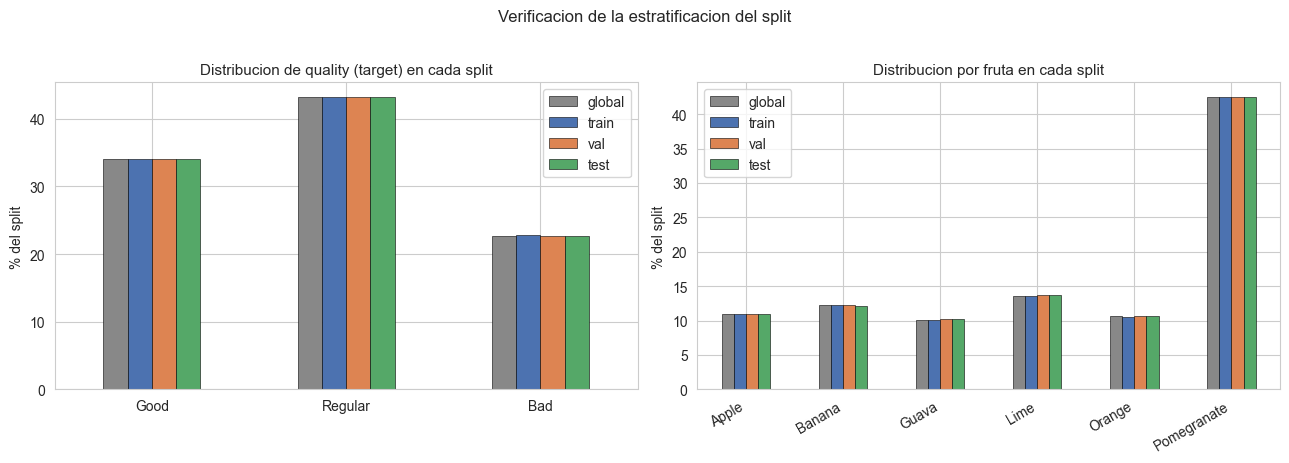


Desviaciones maximas vs global (en puntos porcentuales):
  quality: 0.02
  fruit:   0.08


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) Distribucion de target (3 clases) en cada split
dist = pd.DataFrame({
    "global": df_clean["quality"].value_counts(normalize=True),
    "train":  df_train["quality"].value_counts(normalize=True),
    "val":    df_val["quality"].value_counts(normalize=True),
    "test":   df_test["quality"].value_counts(normalize=True),
}).reindex(CLASS_NAMES) * 100

dist.plot(kind="bar", ax=axes[0], color=["#888","#4c72b0","#dd8452","#55a868"], edgecolor="black", linewidth=0.4)
axes[0].set_title("Distribucion de quality (target) en cada split")
axes[0].set_ylabel("% del split")
axes[0].set_xlabel("")
axes[0].legend(title="")
axes[0].set_xticklabels(CLASS_NAMES, rotation=0)

# (b) Distribucion de las 6 frutas
fruits_order = ["Apple","Banana","Guava","Lime","Orange","Pomegranate"]
fdist = pd.DataFrame({
    "global": df_clean["fruit"].value_counts(normalize=True),
    "train":  df_train["fruit"].value_counts(normalize=True),
    "val":    df_val["fruit"].value_counts(normalize=True),
    "test":   df_test["fruit"].value_counts(normalize=True),
}).reindex(fruits_order) * 100
fdist.plot(kind="bar", ax=axes[1], color=["#888","#4c72b0","#dd8452","#55a868"], edgecolor="black", linewidth=0.4)
axes[1].set_title("Distribucion por fruta en cada split")
axes[1].set_ylabel("% del split")
axes[1].set_xlabel("")
axes[1].legend(title="")
axes[1].set_xticklabels(fruits_order, rotation=30, ha="right")

plt.suptitle("Verificacion de la estratificacion del split", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_verificacion_splits.svg")
plt.show()

print("\nDesviaciones maximas vs global (en puntos porcentuales):")
print(f"  quality: {(dist.subtract(dist['global'], axis=0).abs().drop('global', axis=1).values.max()):.2f}")
print(f"  fruit:   {(fdist.subtract(fdist['global'], axis=0).abs().drop('global', axis=1).values.max()):.2f}")

### 2.2 Persistir los splits

Los CSVs se guardan en `data/processed/`. **No se versionan** (gitignored); cada miembro del equipo los regenera deterministicamente con `python src/data/preprocess.py`.


In [7]:
paths = save_splits(df_train, df_val, df_test, REPO_ROOT / "data" / "processed")
for k, p in paths.items():
    print(f"  {k}: {p}  ({p.exists()})")

[preprocess] Splits guardados en C:\Users\Kevin Cifuentes\Desktop\Estudios\APO3\Proyecto\APO3_TrabajoFinal\APO3_TrabajoFinal\Apo3_ProyectoFinal\data\processed
  train: C:\Users\Kevin Cifuentes\Desktop\Estudios\APO3\Proyecto\APO3_TrabajoFinal\APO3_TrabajoFinal\Apo3_ProyectoFinal\data\processed\train_manifest.csv  (True)
  val: C:\Users\Kevin Cifuentes\Desktop\Estudios\APO3\Proyecto\APO3_TrabajoFinal\APO3_TrabajoFinal\Apo3_ProyectoFinal\data\processed\val_manifest.csv  (True)
  test: C:\Users\Kevin Cifuentes\Desktop\Estudios\APO3\Proyecto\APO3_TrabajoFinal\APO3_TrabajoFinal\Apo3_ProyectoFinal\data\processed\test_manifest.csv  (True)


## 3. Preprocesamiento de imagen (carga + resize + normalizacion)

`load_and_preprocess_image(path)` retorna un array (224, 224, 3) float32 en [0, 1]. Veamos qué pasa con una imagen real.


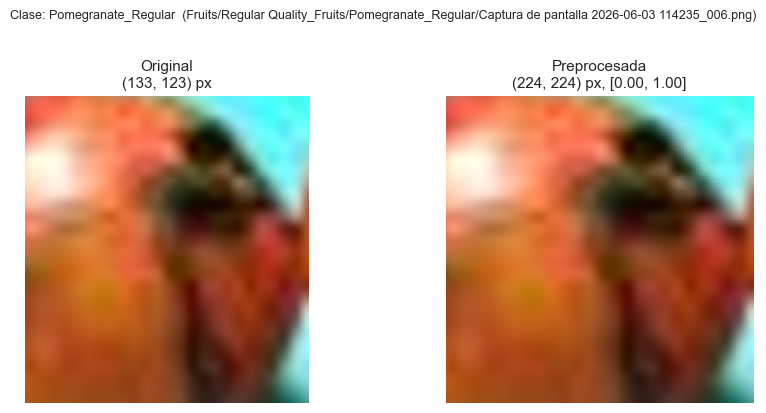

In [8]:
rng = np.random.default_rng(7)
sample = df_train.sample(1, random_state=7).iloc[0]
img_proc = load_and_preprocess_image(REPO_ROOT / sample["path"])

import cv2
img_orig = cv2.cvtColor(cv2.imread(str(REPO_ROOT / sample["path"])), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(img_orig); axes[0].set_title(f"Original\n{img_orig.shape[:2]} px")
axes[0].axis("off")
axes[1].imshow(img_proc); axes[1].set_title(f"Preprocesada\n{img_proc.shape[:2]} px, [{img_proc.min():.2f}, {img_proc.max():.2f}]")
axes[1].axis("off")
plt.suptitle(f"Clase: {sample['class']}  ({sample['path']})", y=1.02, fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_preprocesamiento.svg")
plt.show()

## 4. Data augmentation (solo en train)

`get_train_augmentation()` retorna un pipeline `albumentations` con HorizontalFlip, Rotate(±25°), RandomBrightnessContrast y HueSaturationValue ligero. Se aplica **solo a las imágenes de train**, nunca a val/test.


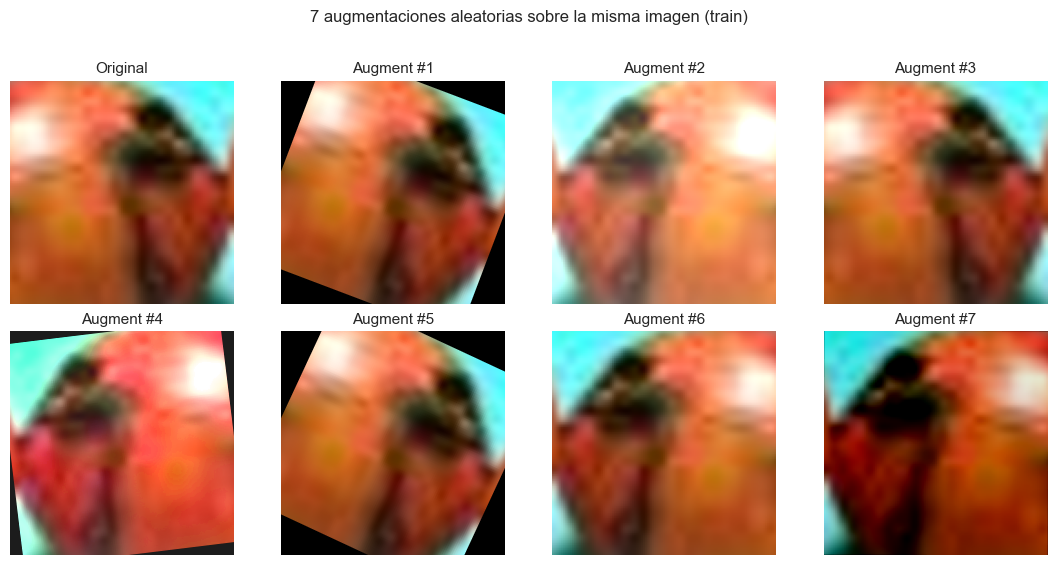

In [9]:
aug = get_train_augmentation()
fig, axes = plt.subplots(2, 4, figsize=(11, 5.5))
axes = axes.flatten()
axes[0].imshow(img_proc); axes[0].set_title("Original"); axes[0].axis("off")
for i in range(1, 8):
    out = aug(image=img_proc)["image"]
    axes[i].imshow(np.clip(out, 0, 1))
    axes[i].set_title(f"Augment #{i}")
    axes[i].axis("off")
plt.suptitle("7 augmentaciones aleatorias sobre la misma imagen (train)", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_augmentation_demo.svg")
plt.show()

## 5. Extracción de features (vector 141-D)

`extract_features(img)` retorna 141 floats: HSV-96 + Hu-7 + LBP-32 + ChannelStats-6. Es el input de SVM y Random Forest. La CNN no usa este vector — recibe píxeles directamente.


In [10]:
N_SAMPLE = 30
sub = df_train.sample(N_SAMPLE, random_state=42)
X = np.stack([extract_features(load_and_preprocess_image(REPO_ROOT / p)) for p in sub["path"]])
y_quality = sub["quality"].values
y_fruit = sub["fruit"].values

print(f"Matriz de features: X.shape = {X.shape}")
print(f"Rango por bloque:")
print(f"  HSV (0:96)      min={X[:, 0:96].min():.4f}  max={X[:, 0:96].max():.4f}")
print(f"  Hu  (96:103)    min={X[:, 96:103].min():.4f}  max={X[:, 96:103].max():.4f}")
print(f"  LBP (103:135)   min={X[:, 103:135].min():.4f}  max={X[:, 103:135].max():.4f}")
print(f"  Stats (135:141) min={X[:, 135:141].min():.4f}  max={X[:, 135:141].max():.4f}")
print(f"\nNombres primeras 5 features: {feature_names()[:5]}")
print(f"Nombres ultimas 6 features:  {feature_names()[-6:]}")

Matriz de features: X.shape = (30, 141)
Rango por bloque:
  HSV (0:96)      min=0.0000  max=0.8373
  Hu  (96:103)    min=-12.0000  max=12.0000
  LBP (103:135)   min=0.0000  max=0.7239
  Stats (135:141) min=0.0345  max=0.8992

Nombres primeras 5 features: ['hsv_H_00', 'hsv_H_01', 'hsv_H_02', 'hsv_H_03', 'hsv_H_04']
Nombres ultimas 6 features:  ['mu_R', 'mu_G', 'mu_B', 'sigma_R', 'sigma_G', 'sigma_B']


### 5.1 Visualización PCA 2D del espacio de features

Una rápida proyección PCA permite ver si las 3 clases tienen alguna separabilidad lineal preliminar. **No es el modelo final** — es un sanity check para confirmar que las features capturan algo de la señal de calidad.


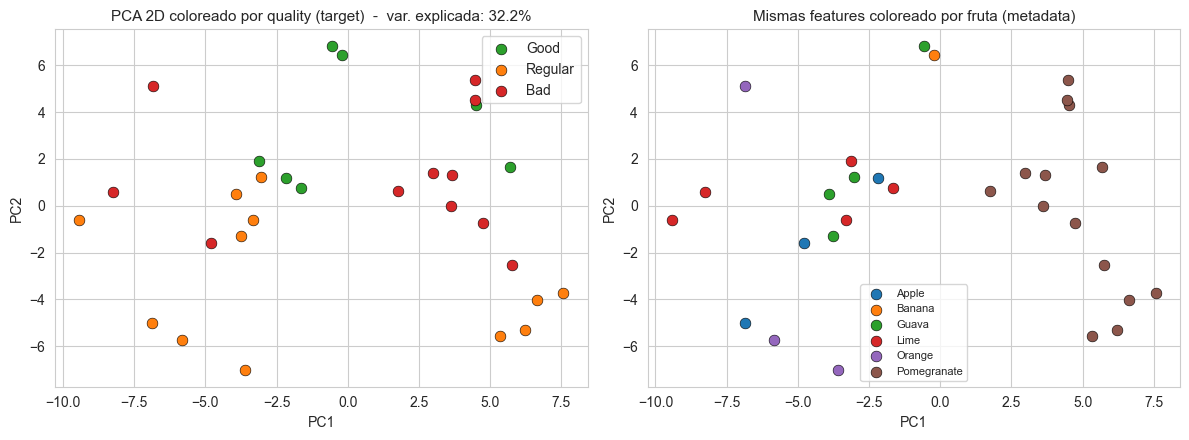


Varianza explicada por PC1: 20.8%
Varianza explicada por PC2: 11.4%


In [11]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
Z = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for q in CLASS_NAMES:
    mask = y_quality == q
    axes[0].scatter(Z[mask, 0], Z[mask, 1], c=QUALITY_COLORS[q], label=q, s=60, edgecolors="black", linewidth=0.4)
axes[0].set_title(f"PCA 2D coloreado por quality (target)  -  var. explicada: {sum(pca.explained_variance_ratio_)*100:.1f}%")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2"); axes[0].legend()

palette = dict(zip(["Apple","Banana","Guava","Lime","Orange","Pomegranate"], sns.color_palette("tab10", 6)))
for f in palette:
    mask = y_fruit == f
    axes[1].scatter(Z[mask, 0], Z[mask, 1], c=[palette[f]], label=f, s=60, edgecolors="black", linewidth=0.4)
axes[1].set_title("Mismas features coloreado por fruta (metadata)")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2"); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "04_pca_features.svg")
plt.show()

print(f"\nVarianza explicada por PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Varianza explicada por PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")

## 6. Decisiones para Fase 3 (Modelado)

Con los datos preparados, las decisiones técnicas para los modelos quedan:

### ML tradicional (SVM, Random Forest)
- **Input:** vector 141-D extraído con `extract_features`.
- **Normalización:** `StandardScaler` ajustado **solo con train** y aplicado a val/test (no data leakage).
- **Hiperparámetros:** `GridSearchCV` con 5-fold sobre train. Métrica de optimización: **F1-macro** (justa con clases ligeramente desbalanceadas).
- **class_weight='balanced'** por consistencia, aunque IR=2.06 es leve.

### CNN
- **Input:** imagen 224×224×3 en [0, 1] (no features handcrafted).
- **Augmentation:** solo en train, con el pipeline ya implementado.
- **Pérdida:** entropía cruzada categórica + class_weight inverso a frecuencia.
- **Hiperparámetros a tunear:** learning rate, dropout, batch size. Optimizer Adam.
- **Early stopping** sobre val loss para evitar overfit.

### Evaluación (Fase 4)
- Reportar accuracy, precision, recall y F1 (por clase y macro) sobre **test**.
- Matriz de confusión 3×3 (target) y matriz 6×6 marginal por fruta (sesgo).
- Accuracy condicional por fruta para responder: *¿el modelo aprende calidad o atajos por especie?*

## Siguiente paso

Notebook `03_modelado_ml.ipynb`: entrenar SVM y Random Forest con GridSearchCV.
